# Analyse de données

### Importation des packages nécessaire

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy.stats import chi2_contingency, f_oneway
from fanalysis.ca import CA
import prince
from sklearn.preprocessing import StandardScaler

### Importation du fichier contenant les données à traiter

In [36]:
data = pd.read_excel("data/afc_data.xlsx")
data.head()

,Name,Survived,Pclass,Sex,Age,SibSp,Fare,Embarked
0,"Braund, Mr. Owen Harris",0,3,1,22.0,1,7.2500,1.0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,1,0,38.0,1,71.2833,2.0
2,"Heikkinen, Miss. Laina",1,3,0,26.0,0,7.9250,1.0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,1,0,35.0,1,53.1000,1.0
4,"Allen, Mr. William Henry",0,3,1,35.0,0,8.0500,1.0


### Analyse Factorielle des correspondances (AFC)

**Objectif**
- Savoir s'il y existe une relation entre les passagers à bord du Titanic
- Savoir si les classes, le sexe et les ports d'embarquement sont liés d'une manière qui pourrait nous aider à comprendre comment ces facteurs influencent la répartition des passagers à bord du Titanic.
- Savoir si le survie d'un passager dépendent de la classe, l'age et le sexe du passager.

##### AFC 1 - Savoir s'il y existe une relation entre les passagers à bord du Titanic 

In [37]:
df_afc_1 = data.copy().dropna(axis=0)
df_afc_1.head()

,Name,Survived,Pclass,Sex,Age,SibSp,Fare,Embarked
0,"Braund, Mr. Owen Harris",0,3,1,22.0,1,7.2500,1.0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,1,0,38.0,1,71.2833,2.0
2,"Heikkinen, Miss. Laina",1,3,0,26.0,0,7.9250,1.0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,1,0,35.0,1,53.1000,1.0
4,"Allen, Mr. William Henry",0,3,1,35.0,0,8.0500,1.0


In [38]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Fare', 'Embarked']

In [39]:
df_afc_1[features]

,Pclass,Sex,Age,SibSp,Fare,Embarked
0,3,1,22.0,1,7.2500,1.0
1,1,0,38.0,1,71.2833,2.0
2,3,0,26.0,0,7.9250,1.0
3,1,0,35.0,1,53.1000,1.0
4,3,1,35.0,0,8.0500,1.0
...,...,...,...,...,...,...
707,1,1,39.0,0,26.2875,1.0
708,1,0,27.0,0,151.5500,1.0
709,3,1,19.0,1,15.2458,2.0
710,1,0,26.0,0,49.5042,2.0


In [40]:
# Normalisation des données avant l'ACP
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_afc_1[features].dropna())

In [42]:
from sklearn.decomposition import PCA

# Appliquer l'ACP
pca = PCA(n_components=2)  # Réduire les données à 2 dimensions
pca_result = pca.fit_transform(data_scaled)

# Visualiser la variance expliquée par chaque composante
print(f"Variance expliquée par la première composante : {pca.explained_variance_ratio_[0]:.2f}")
print(f"Variance expliquée par la deuxième composante : {pca.explained_variance_ratio_[1]:.2f}")

Variance expliquée par la première composante : 0.27
Variance expliquée par la deuxième composante : 0.19


In [43]:
# Créer un DataFrame pour les résultats PCA
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])

In [44]:
pca_df.head()

,PC1,PC2
0,-1.070071,0.303614
1,2.046210,-0.974898
2,-0.544476,-0.572445
3,1.664920,-0.118668
4,-1.252704,0.597375


In [45]:
df_afc_1["Survived"]

0      0
1      1
2      1
3      1
4      0
      ..
707    1
708    1
709    1
710    1
711    0
Name: Survived, Length: 711, dtype: int64

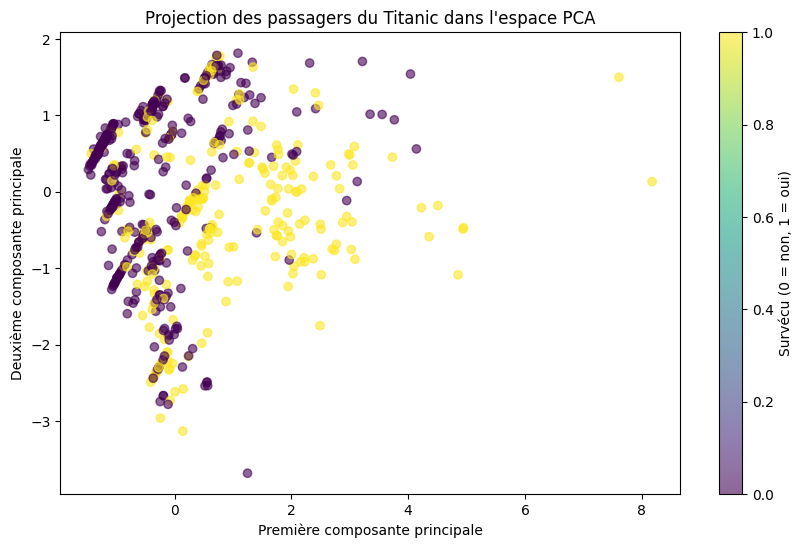

In [48]:
# Visualisation
plt.figure(figsize=(10, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=df_afc_1['Survived'], cmap='viridis', alpha=0.6)
plt.title('Projection des passagers du Titanic dans l\'espace PCA')
plt.xlabel('Première composante principale')
plt.ylabel('Deuxième composante principale')
plt.colorbar(label='Survécu (0 = non, 1 = oui)')
plt.show()

**Conclusion**

- ***Analyse des résultats :*** Vous pouvez examiner les composants principaux et la variance expliquée par chaque composante. Si les passagers sont bien séparés selon les composants principaux, cela pourrait indiquer qu'il existe une structure ou une relation sous-jacente intéressante dans les données.
- ***Visualisation :*** Les points colorés dans la visualisation montrent la relation entre la survie (variable cible) et les autres caractéristiques des passagers. Si des clusters apparaissent, cela pourrait suggérer des facteurs qui influencent la survie (par exemple, les passagers de première classe qui ont survécu).

##### AFC 2 - Savoir si les classes, le sexe et les ports d'embarquement sont liés d'une manière qui pourrait nous aider à comprendre comment ces facteurs influencent la répartition des passagers à bord du Titanic 

In [49]:
df_afc_2 = data.copy()

In [50]:
# Sélectionner les colonnes pertinentes pour l'AFC
df_afc_2 = df_afc_2[['Pclass', 'Sex', 'Embarked']].dropna()

# Créer une table de contingence
contingency_table = pd.crosstab([df_afc_2['Pclass'], df_afc_2['Sex']], df_afc_2['Embarked'])

print(contingency_table)

# Convertir la table de contingence en une matrice numpy
contingency_matrix = contingency_table.values

Embarked    1.0  2.0  3.0
Pclass Sex               
1      0     48   43    1
       1     79   42    1
2      0     67    7    2
       1     97   10    1
3      0     88   23   33
       1    265   43   39


In [52]:
# Calculer la matrice des profils (normée)
n_rows, n_cols = contingency_matrix.shape
row_totals = contingency_matrix.sum(axis=1)
col_totals = contingency_matrix.sum(axis=0)
grand_total = contingency_matrix.sum()

# Profils des lignes et des colonnes
row_profiles = contingency_matrix / row_totals[:, np.newaxis]
col_profiles = contingency_matrix / col_totals[np.newaxis, :]

# Calculer la matrice des résidus
expected_matrix = np.outer(row_totals, col_totals) / grand_total
residuals = contingency_matrix - expected_matrix

In [53]:
# Appliquer la décomposition en valeurs singulières (SVD)
U, S, Vt = np.linalg.svd(residuals, full_matrices=False)

# Obtenir les coordonnées des lignes et des colonnes
row_coordinates = U[:, :2] * S[:2]
col_coordinates = Vt.T[:, :2] * S[:2]

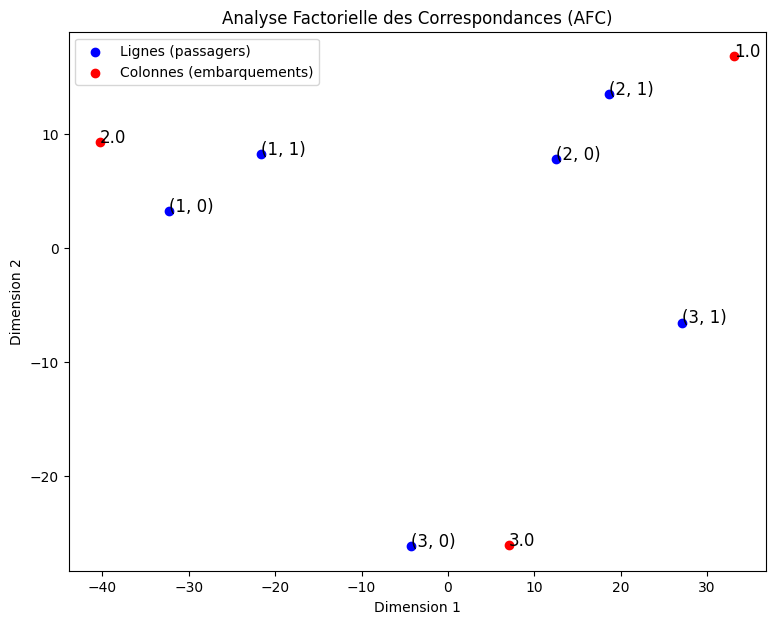

In [54]:
# Visualisation des résultats
plt.figure(figsize=(9, 7))

# Ploter les coordonnées des lignes (passagers)
plt.scatter(row_coordinates[:, 0], row_coordinates[:, 1], color='blue', label='Lignes (passagers)')
for i, label in enumerate(contingency_table.index):
    plt.text(row_coordinates[i, 0], row_coordinates[i, 1], label, fontsize=12)

# Ploter les coordonnées des colonnes (embarquements)
plt.scatter(col_coordinates[:, 0], col_coordinates[:, 1], color='red', label='Colonnes (embarquements)')
for i, label in enumerate(contingency_table.columns):
    plt.text(col_coordinates[i, 0], col_coordinates[i, 1], label, fontsize=12)

# Ajouter des titres et légendes
plt.title('Analyse Factorielle des Correspondances (AFC)')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
#plt.legend(loc='upper right')
plt.legend()
plt.show()

##### AFC 3 : Savoir si le survie d'un passager dépendent de la classe, l'age et le sexe du passager.

**Hypothèse**

- ***H0*** : La survie d'un passager est strictement indépendent de la classe, l'age et le sexe du passager
- ***H1*** : La survie d'un passager dépendent de la classe, l'age et le sexe du passager

In [55]:
df_afc_3 = data.copy()
df_afc_3

,Name,Survived,Pclass,Sex,Age,SibSp,Fare,Embarked
0,"Braund, Mr. Owen Harris",0,3,1,22.0,1,7.2500,1.0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,1,0,38.0,1,71.2833,2.0
2,"Heikkinen, Miss. Laina",1,3,0,26.0,0,7.9250,1.0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,1,0,35.0,1,53.1000,1.0
4,"Allen, Mr. William Henry",0,3,1,35.0,0,8.0500,1.0
...,...,...,...,...,...,...,...,...
886,"Montvila, Rev. Juozas",0,2,1,NaN,0,13.0000,1.0
887,"Graham, Miss. Margaret Edith",1,1,0,NaN,0,30.0000,1.0
888,"Johnston, Miss. Catherine Helen ""Carrie""",0,3,0,NaN,1,23.4500,1.0
889,"Behr, Mr. Karl Howell",1,1,1,NaN,0,30.0000,2.0


In [56]:
# Sélectionner les colonnes pertinentes pour l'AFC
df_afc_3 = df_afc_3[['Pclass', 'Sex', 'Age', 'Survived']].dropna()

# Créer une table de contingence
contingency_table_3 = pd.crosstab([df_afc_3['Pclass'],df_afc_3['Age'], df_afc_3['Sex']], df_afc_3['Survived'])

# Caclul de la distance de Chi2
pvalue = chi2_contingency(contingency_table_3).pvalue

In [57]:
if pvalue > 0.05:
    print("On ne peut pas rejeter l'hypothèse H0\n''' La survie d'un passager est strictement indépendent de la classe, l'age et le sexe du passager '''")
else:
    print("On rejete l'hypothèse H0\n'''La survie d'un passager dépendent de la classe, l'age et le sexe du passage '''")

On rejete l'hypothèse H0
'''La survie d'un passager dépendent de la classe, l'age et le sexe du passage '''


### ANOVA: Analyse des Varience

**Objectif**

Déterminer si les moyennes des tarifs sont différentes entre les trois classes (1ère, 2ème, et 3ème classe) c'est-à-dire vérifier si le tarif (la colonne Fare) varie significativement en fonction de la classe du passager (la colonne Pclass)

In [60]:
data_anova = pd.read_excel("./data/filtered_data.xlsx")
data_anova.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",0,22.0,1,7.2500,2
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,71.2833,0
2,1,3,"Heikkinen, Miss. Laina",1,26.0,0,7.9250,2
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,53.1000,2
4,0,3,"Allen, Mr. William Henry",0,35.0,0,8.0500,2


In [61]:
# Prétraiter les données : éliminer les valeurs manquantes dans les colonnes 'Fare' et 'Pclass'
df_clean = data_anova.dropna(subset=['Fare', 'Pclass'])
df_clean.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",0,22.0,1,7.2500,2
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,71.2833,0
2,1,3,"Heikkinen, Miss. Laina",1,26.0,0,7.9250,2
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,53.1000,2
4,0,3,"Allen, Mr. William Henry",0,35.0,0,8.0500,2


In [62]:
# Diviser les données en groupes selon la classe (Pclass)
group_1 = df_clean[df_clean['Pclass'] == 1]['Fare']  # 1ère classe
group_2 = df_clean[df_clean['Pclass'] == 2]['Fare']  # 2ème classe
group_3 = df_clean[df_clean['Pclass'] == 3]['Fare']  # 3ème classe


In [63]:
print("Groupe 1: \n {}\n ---------------".format(group_1))

Groupe 1: 
 1      71.2833
3      53.1000
5      51.8625
10     26.5500
20     35.5000
        ...   
694    52.5542
695     5.0000
701    83.1583
709    30.0000
710    30.0000
Name: Fare, Length: 184, dtype: float64
 ---------------


In [64]:
print("Groupe 2: \n {}\n ---------------".format(group_2))

Groupe 2: 
 8      30.0708
14     16.0000
17     26.0000
18     13.0000
25     10.5000
        ...   
690    13.8583
697    24.0000
702    26.0000
705    10.5000
708    13.0000
Name: Fare, Length: 173, dtype: float64
 ---------------


In [65]:
print("Groupe 3: \n {}\n ---------------".format(group_3))

Groupe 3: 
 0       7.2500
2       7.9250
4       8.0500
6      21.0750
7      11.1333
        ...   
703     7.8958
704    10.5167
706     7.0500
707    29.1250
711     7.7500
Name: Fare, Length: 355, dtype: float64
 ---------------


In [97]:
# Effectuer l'ANOVA
f_stat, p_value = f_oneway(group_1, group_2, group_3)

# Afficher les résultats de l'ANOVA
print(f"Statistique F : {f_stat}")
print(f"PValeur : {p_value}")

Statistique F : 199.51520026428128
PValeur : 1.821885989198717e-69


In [67]:
# Interpréter les résultats
if p_value < 0.05:
    print("Il y a une différence significative entre les moyennes des classes.")
else:
    print("Il n'y a pas de différence significative entre les moyennes des classes.")

Il y a une différence significative entre les moyennes des classes.


**Interprétation des résultats :**

- ***Statistique F :*** Elle compare la variation entre les groupes par rapport à la variation au sein des groupes. Plus cette statistique est élevée, plus il est probable qu'il existe une différence significative.
- ***PValeur :*** Si elle est inférieure à 0.05 (niveau de signification habituel), cela signifie qu'il y a une différence statistiquement significative entre les moyennes des tarifs des différentes classes. Si elle est supérieure à 0.05, il n'y a pas de différence significative.

**Resultat**

Le tarif moyen payé par les passagers varie en fonction de leur classe à bord du Titanic.



### Model de machine learning

**Objectif :**
Développer un model de machine learning permettant de savoir sur une personne quelconque va survivre s'il était à bord du Titanic. On va prendre en compte son Age, son sexe, la classe

***NB :*** Ce sont les critères dont on a vue lors de l'analyse AFC

In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [69]:
ml_dataset = pd.read_excel("./data/ml.xlsx")
ml_dataset = ml_dataset.dropna(axis=0)

In [70]:
X = ml_dataset[["Pclass", "Sex", "Age"]]
y = ml_dataset['Survived']

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((569, 3), (143, 3), (569,), (143,))

In [72]:
# Création du model 'Random Forest'
num_trees = 50
model = RandomForestClassifier(n_estimators=num_trees, max_depth=4, class_weight='balanced')
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=4, n_estimators=50)

In [73]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
print("AUC Train: {:.4f}\nAUF Test: {:.4f}".format(metrics.roc_auc_score(y_train, y_train_pred), metrics.roc_auc_score(y_test, y_test_pred)))

AUC Train: 0.7346
AUF Test: 0.5886


In [85]:
score_train = model.score(X_train, y_train)
score_test = model.score(X_test, y_test)
print("Score Train: {}\nScore Test: {}".format(score_train, score_test))

Score Train: 0.7311072056239016
Score Test: 0.5944055944055944


In [89]:
X_train

,Pclass,Sex,Age
375,2.0,0,33.0
344,2.0,1,42.0
526,2.0,0,25.0
24,1.0,0,40.0
234,1.0,1,19.0
...,...,...,...
71,3.0,0,26.0
106,2.0,0,23.0
270,3.0,1,45.0
435,2.0,0,8.0


In [86]:
new_data = pd.DataFrame([[1, 0, 23]])

In [81]:
custome_pred = model.predict(new_data)

/home/rantodev/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [82]:
if custome_pred == 1:
    print("True")
else:
    print("Fase")

True


In [150]:
# Save model
from joblib import dump
dump(model, './model/model.joblib')

['./model/model.joblib']

{
  "classe_passager": 1,
  "sexe":"homme",
  "age":22
}